# LIBRAIRIES

In [33]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

# Taille de police par défaut pour toutes les figures
plt.rcParams['font.size'] = 16


# DATA

In [34]:
# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────

root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth


In [35]:
# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────

mu    = 150
theta = 100
s_selected = 35

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM


In [36]:
# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────

ARRAY_COLS = ["results", "results_mean", "alpha_mean_a"]

df_data = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("s")     == s_selected)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

print(df_data)
print(df_data.columns)


shape: (445, 64)
┌──────┬───────┬──────┬──────┬───┬────────┬───────────┬────────────┬─────┐
│ algo ┆ fact  ┆ mode ┆ dstr ┆ … ┆ alpha0 ┆ bound_low ┆ bound_high ┆ lb  │
│ ---  ┆ ---   ┆ ---  ┆ ---  ┆   ┆ ---    ┆ ---       ┆ ---        ┆ --- │
│ str  ┆ bool  ┆ str  ┆ bool ┆   ┆ i64    ┆ i64       ┆ i64        ┆ i64 │
╞══════╪═══════╪══════╪══════╪═══╪════════╪═══════════╪════════════╪═════╡
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ …    ┆ …     ┆ …    ┆ …    ┆ … ┆ …      ┆ …         ┆ …          ┆ …   │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 1S   ┆

In [37]:
# ─────────────────────────────────────────────
# SOUS-ENSEMBLES : PERIODIC / HOMOGEN / RANDOM
# ─────────────────────────────────────────────

df_periodic = (
    df_data
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_periodic)
)

df_homogen = (
    df_data
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_homogen)
)

df_random = (
    df_data
    .filter(pl.col("land") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin") == bpmin_random)
)

print(f"periodic (alphad={alphad_periodic}) : {df_periodic.height} lignes")
print(f"homogen  (alphad={alphad_homogen})  : {df_homogen.height} lignes")
print(f"random   (bpmin={bpmin_random})     : {df_random.height} lignes")


periodic (alphad=0.0) : 20 lignes
homogen  (alphad=1.0)  : 20 lignes
random   (bpmin=0)     : 45 lignes


# FIGURE 1 — VITESSES EN SITE (v_mean) EN FONCTION DE l

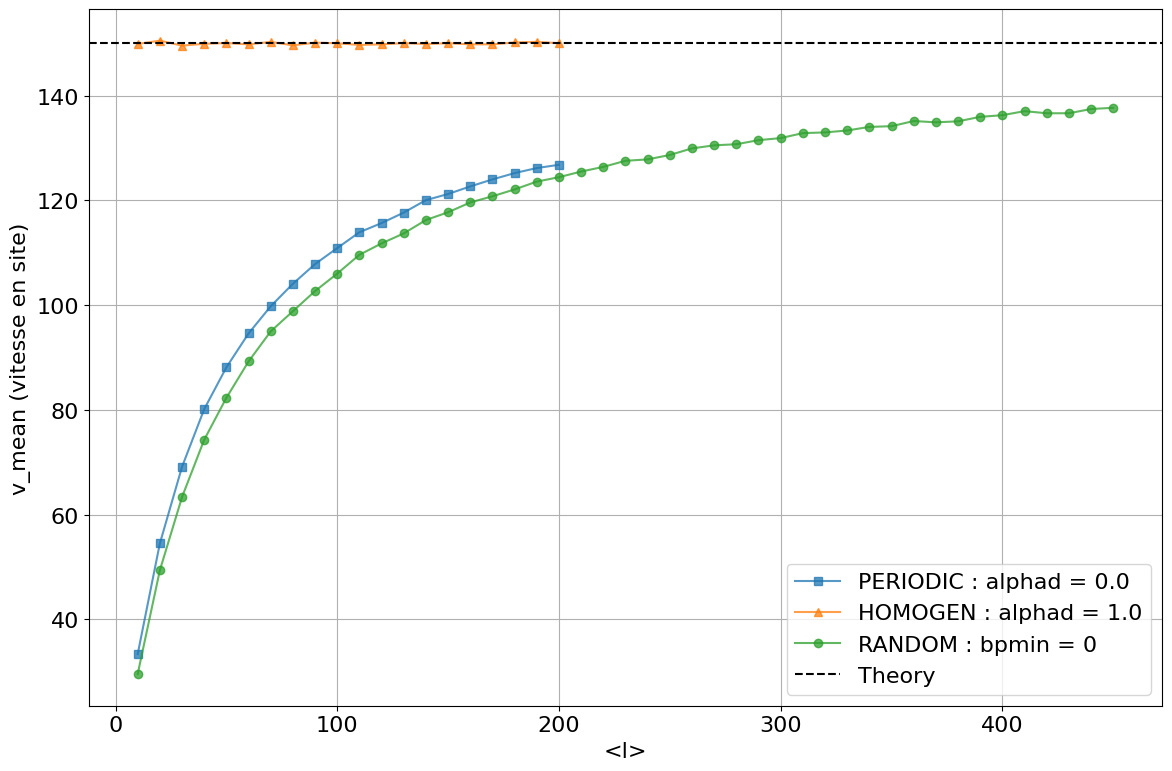

In [14]:
# ─────────────────────────────────────────────
# FIGURE - VITESSES EN SITE (v_mean vs l)
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 8))

# PERIODIC (alphad = 0)
l_periodic = df_periodic["l"].to_numpy()
v_periodic = df_periodic["v_mean"].to_numpy()
ax.plot(l_periodic, v_periodic, marker="s", ls="-", alpha=0.75,
        label=f"PERIODIC : alphad = {alphad_periodic}")

# HOMOGEN (alphad = 1.0, equivalent periodique homogene)
l_homogen = df_homogen["l"].to_numpy()
v_homogen = df_homogen["v_mean"].to_numpy()
ax.plot(l_homogen, v_homogen, marker="^", ls="-", alpha=0.75,
        label=f"HOMOGEN : alphad = {alphad_homogen}")

# RANDOM (bpmin = 0)
l_random = df_random["l"].to_numpy()
v_random = df_random["v_mean"].to_numpy()
ax.plot(l_random, v_random, marker="o", ls="-", alpha=0.75,
        label=f"RANDOM : bpmin = {bpmin_random}")

ax.axhline(mu, c="k", ls="--", label="Theory")

ax.set_xlabel("<l>")
ax.set_ylabel("v_mean (vitesse en site)")
ax.legend(loc="best")
ax.grid(True)

plt.tight_layout()
plt.show()


# FIGURE 2 — COMPACTION EN FONCTION DE l_mean

In [32]:
# ─────────────────────────────────────────────
# FIGURE - COMPACTION vs l_mean
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)

# # PERIODIC (alphad = 0)
# l_mean_periodic = df_periodic["l_mean"].to_numpy()
# c_periodic = (150 + l_mean_periodic) / (35 + l_mean_periodic)
# ax.plot(l_mean_periodic, c_periodic, marker="s", ls="-", alpha=0.75,
#         label=f"PERIODIC : alphad = {alphad_periodic}")

# # HOMOGEN (alphad = 1.0)
# l_mean_homogen = df_homogen["l_mean"].to_numpy()
# c_homogen = (150 + l_mean_homogen) / (35 + l_mean_homogen)
# ax.plot(l_mean_homogen, c_homogen, marker="^", ls="-", alpha=0.75,
#         label=f"HOMOGEN : alphad = {alphad_homogen}")

# RANDOM (bpmin = 0)
l_mean_random = df_random["l_mean"].to_numpy()
c_random = (150 + l_mean_random) / (35 + l_mean_random)
ax.plot(l_mean_random, c_random, marker="o", ls="-", alpha=0.75)

ax.set_xlabel(r"$<l>$")
ax.set_ylabel(r"$c$")
ax.grid(True, alpha=0.30)

plt.tight_layout()
plt.show()


In [42]:
# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────

root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19")
paths = [str(p) for p in root.glob("nucleo__*")]

mu    = 150
theta = 100
s_selected = 150




ARRAY_COLS = []

df_data = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("s")     == s_selected)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

print(df_data)
print(df_data.columns)


# ─────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────

plt.figure(figsize=(8,6), dpi=1200)

df_periodic = df_data.filter(
    pl.col("land") == "periodic"
)
l_periodic = df_periodic["l"].to_numpy()
v_periodic = df_periodic["v_mean"].to_numpy()
plt.plot(l_periodic, v_periodic, marker ="s", label="Periodic")

df_random = df_data.filter(
    (pl.col("land") == "random") &
    (pl.col("bpmin") == 0)
)
l_random = df_random["l"].to_numpy()
v_random = df_random["v_mean"].to_numpy()
plt.plot(l_random, v_random, marker ="o", label="Random")

df_homogen = df_data.filter(
    (pl.col("land") == "random") &
    (pl.col("bpmin") == 0)
)

l_homogen = df_random["l"].to_numpy()
v_homogen = 150 * (l_homogen / (s_selected + l_homogen))
plt.plot(l_homogen, v_homogen, marker ="^", label="Homogen")


plt.xlabel(r"$l$")
plt.ylabel(r"$v^{site}_{mean}$")
plt.grid(True, alpha=0.30)
plt.legend(loc="best")
plt.show()

shape: (22, 61)
┌──────┬───────┬──────┬───────┬───┬───────┬───────────────┬────────────┬───────┐
│ algo ┆ fact  ┆ mode ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean       ┆ dt_med     ┆ dt_mp │
│ ---  ┆ ---   ┆ ---  ┆ ---   ┆   ┆ ---   ┆ ---           ┆ ---        ┆ ---   │
│ str  ┆ bool  ┆ str  ┆ bool  ┆   ┆ f64   ┆ f64           ┆ f64        ┆ f64   │
╞══════╪═══════╪══════╪═══════╪═══╪═══════╪═══════════════╪════════════╪═══════╡
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 108.5 ┆ 15.967046     ┆ 11.086598  ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 155.5 ┆ 41.734724     ┆ 29.071758  ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 160.5 ┆ 21.491827     ┆ 14.942383  ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 160.5 ┆ 21.602681     ┆ 14.983757  ┆ 1.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 165.5 ┆ 14.78374      ┆ 10.23658   ┆ 0.5   │
│ …    ┆ …     ┆ …    ┆ …     ┆ … ┆ …     ┆ …             ┆ …          ┆ …     │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 179.5 ┆ 4.76617       ┆ 2.346321   ┆ 0.5   │
│ 1S   ┆ fal